In [19]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import uuid
from copy import deepcopy
from typing import Literal
from overview import FigureType, feature_overview

import numpy as np
import pandas as pd
import sklearn.preprocessing as pre
from sklearn.pipeline import make_pipeline

# from processors import temparature, season, month
from transforming import (
    Apply, Bins, Calc, Fill, Group, KeepDataframe, Lag, Select, Swap,
    TypeRecast, WithSelected,
    boruta
)

# modeling dependencies
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
# from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import root_mean_squared_log_error
import matplotlib.pyplot as plt


TARGET = 'Calories'
USED_COLUMNS = ['']

# load dataetition dataset
comp = pd.read_csv('data/train.csv', index_col='id').astype({'Sex': 'category'})
# load original dataset
orig = pd.read_csv('data/calories.csv', index_col='User_ID').rename(columns={'Gender': 'Sex'}).astype({'Sex': 'category'})
# concatenate
df = pd.concat([comp, orig]).reset_index(drop=True)

# load test part
test = pd.read_csv('data/test.csv', index_col='id')
test[TARGET] = 0

In [20]:
df.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [21]:
def checkup(estimator_base, X, y, folds=7):
    metrics = []
    # kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    kf = KFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train])

        pt = estimator.predict(X.loc[train])
        pv = estimator.predict(X.loc[valid])

        RMSLE_train = root_mean_squared_log_error(y[train], pt)
        RMSLE_valid = root_mean_squared_log_error(y[valid], pv)

        metrics.append((RMSLE_train, RMSLE_valid))
        print(f'Fold: {f}; TRAIN RMSLE={RMSLE_train:.5f}; | VALID RMSLE={RMSLE_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN RMSLE={means[0]:.5f}; | VALID RMSLE={means[1]:.5f}')
    return estimator

__Feature engineering__

In [22]:
ORIGIN = df.columns.to_list()

pipe = make_pipeline(
    # Recast categories
    # Calc('Sex.cat.codes', to='Sex'),
    Calc('(Sex == "male").astype(int)', to='Sex'),
    # Body-mass index
    Calc('Weight / (Height / 100) ** 2', to='BMI'),

    # WTF
    Calc('np.log(Heart_Rate * Body_Temp / Duration)', to='activity_index'),

    # bins
    Bins('Duration', to='ct_Duration', bins=10),
    Bins('Age', to='ct_Age', bins=10),

    # groups
    WithSelected(r'(?!Sex|ct_.*)')(Group('Age', 'mean', prefix='mean_Age_')),
    # WithSelected(['ct_Duration'])(Group('ct_Duration', 'mean', prefix='mean_ct_Duration_', include_target=True)),
    WithSelected(['Sex', 'Age'])(Group(['Sex', 'Age'], 'mean', prefix='mean_SexAge_', include_target=True)),


    # fix temperatures
    # WithSelected(TEMPERATURES, prefix='')(
    #     Calc(lambda x: x.min(), to='_mintemp'),
    #     Calc(lambda x: x.max(), to='_maxtemp'),
    #     Calc(temparature, to='_temparature'),
    # ),
    # Select(TEMPERATURES, mode='drop'),

    # categories
    # Bins('cloud', to='ct_cloud', bins=10, as_='code'),
    # Bins('humidity', to='ct_humidity', bins=10, as_='code'),
    # Bins('sunshine', to='ct_sunshine', bins=10, as_='code'),

    # statistics on categories
    # WithSelected(r'(?!day|ct_(?!month)|mean_).*')(Group('ct_month', 'mean', prefix='mean_ct_month_', include_target=False)),
    # WithSelected(r'(?!day|ct_(?!season)|mean_).*')(Group('ct_season', 'mean', prefix='mean_ct_season_', include_target=False)),

    # rainfall statistics
    # WithSelected(['day'])(Group('day', 'median', prefix='median_day_', include_target=True)),
    # WithSelected(['day'])(Group('day', 'mean', prefix='mean_day_', include_target=True)),
    # NOTE these following 3 features are logically incorrect: test df has values that are not present in train df
    # WithSelected(['cloud'])(Group('cloud', 'mean', prefix='mean_cloud_', include_target=True)),
    # WithSelected(['humidity'])(Group('humidity', 'mean', prefix='mean_humidity_', include_target=True)),
    # WithSelected(['sunshine'])(Group('sunshine', 'mean', prefix='mean_sunshine_', include_target=True)),

    # WithSelected(['ct_cloud'])(Group('ct_cloud', 'mean', prefix='mean_ct_cloud_', include_target=True)),
    # WithSelected(['ct_humidity'])(Group('ct_humidity', 'mean', prefix='mean_ct_humidity_', include_target=True)),
    # WithSelected(['ct_sunshine'])(Group('ct_sunshine', 'mean', prefix='mean_ct_sunshine_', include_target=True)),

    # WithSelected(r'(?!ct_|mean_|median_)')(Group('day', 'median', prefix='median_day_', include_target=False)),
    # WithSelected(r'(?!day|ct_(?!cloud)|mean_|median_)')(Group('ct_cloud', 'median', prefix='median_ct_cloud_', include_target=True)),
    # WithSelected(r'(?!day|ct_(?!humidity)|mean_|median_)')(Group('ct_humidity', 'median', prefix='median_ct_humidity_', include_target=True)),
    # WithSelected(r'(?!day|ct_(?!sunshine)|mean_|median_)')(Group('ct_sunshine', 'median', prefix='median_ct_sunshine_', include_target=False)),

    # WithSelected(r'(?!ct_|mean_|median_)')(Group('day', 'mean', prefix='mean_day_', include_target=False)),
    # WithSelected(r'(?!day|ct_(?!cloud)|mean_|median_)')(Group('ct_cloud', 'mean', prefix='mean_ct_cloud_', include_target=True)),
    # WithSelected(r'(?!day|ct_(?!humidity)|mean_|median_)')(Group('ct_humidity', 'mean', prefix='mean_ct_humidity_', include_target=True)),
    # WithSelected(r'(?!day|ct_(?!sunshine)|mean_|median_)')(Group('ct_sunshine', 'mean', prefix='mean_ct_sunshine_', include_target=True)),


    # WithSelected(['ct_sunshine', 'ct_humidity', 'ct_cloud'])(
    # WithSelected(r'(?!day|ct_(?!month|sunshine|humidity|cloud)|mean_|median_)')(
    #     Group(['ct_month', 'ct_sunshine', 'ct_humidity', 'ct_cloud'], 'median', prefix='median_ct_complex_', include_target=False)
    #     # Group(['ct_month', 'ct_sunshine', 'ct_humidity', 'ct_cloud'], 'median', prefix='median_ct_complex_', include_target=True)
    # ),

    # WithSelected(r'(?!day|ct_(?!season|cloud)|mean_|median_)')(
    #     Group(['ct_season', 'ct_cloud'], 'mean', prefix='mean_ct_complex1_', include_target=True)
    # ),
    # WithSelected(r'(?!day|ct_(?!season|humidity)|mean_|median_)')(
    #     Group(['ct_season', 'ct_humidity'], 'mean', prefix='mean_ct_complex2_', include_target=False)
    # ),
    # WithSelected(r'(?!day|ct_(?!season|sunshine)|mean_|median_)')(
    #     Group(['ct_season', 'ct_sunshine'], 'mean', prefix='mean_ct_complex3_', include_target=False)
    # ),

    # previous days
    # WithSelected(['humidity', 'cloud', 'sunshine'], prefix='lag1_mean_')(Lag(1, 'mean')),
    # WithSelected(['humidity', 'cloud', 'sunshine'], prefix='lag2_mean_')(Lag(2, 'mean')),
    # WithSelected(['humidity', 'cloud', 'sunshine'], prefix='lag3_mean_')(Lag(3, 'mean')),
    # WithSelected(['sunshine', 'cloud'], prefix='last_3days_mean_')(Lag(3, 'mean')),
    # WithSelected(['sunshine'], prefix='yesterday_')(Lag(1, 'mean')),
    # WithSelected(['sunshine'], prefix='last_3days_mean_')(Lag(3, 'mean')),

    # drop columns
    # Select(['Sex', 'Age', 'Height'], mode='drop'),
    # Fill('mean'),

    # KeepDataframe(pre.QuantileTransformer(random_state=17)),
    # KeepDataframe(make_pipeline(
    #     pre.StandardScaler(),
    #     pre.PowerTransformer(standardize=False)
    # )),
    # KeepDataframe(pre.PowerTransformer(standardize=True)),
    # KeepDataframe(pre.StandardScaler()),
    # KeepDataframe(pre.RobustScaler()),

    # KeepDataframe(make_pipeline(
    #     pre.QuantileTransformer(random_state=17),
    #     pre.PowerTransformer(standardize=True)
    #     # pre.MinMaxScaler(),
    # ))
)

X: pd.DataFrame = pipe.fit_transform(df.drop(columns=TARGET), df[TARGET])     # type: ignore
y = df[TARGET]
X

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,activity_index,ct_Duration,ct_Age,mean_Age_Height,mean_Age_Weight,mean_Age_Duration,mean_Age_Heart_Rate,mean_Age_Body_Temp,mean_Age_BMI,mean_Age_activity_index,mean_SexAge_Calories
0,1,36,189.0,82.0,26.0,101.0,41.0,22.955684,5.070596,8,2,175.593031,75.913707,15.832775,95.948031,40.073342,24.393312,5.690021,90.214915
1,0,64,163.0,60.0,8.0,85.0,39.7,22.582709,6.044561,2,7,174.458711,76.228978,15.569041,95.892241,40.079355,24.744063,5.729221,95.325732
2,0,51,161.0,64.0,7.0,84.0,39.8,24.690405,6.168774,2,5,176.600012,78.083669,14.425826,94.168029,39.934198,24.779509,5.831930,87.459060
3,1,20,192.0,90.0,25.0,105.0,40.7,24.414062,5.141313,8,0,173.754044,72.756440,14.386139,94.507563,39.941695,23.865488,5.802021,66.872781
4,0,38,166.0,61.0,25.0,102.0,40.6,22.136740,5.109865,8,3,176.013709,76.577027,14.765258,94.616213,39.965536,24.484258,5.786085,83.783366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764995,0,20,193.0,86.0,11.0,92.0,40.4,23.087868,5.822723,3,0,173.754044,72.756440,14.386139,94.507563,39.941695,23.865488,5.802021,71.963791
764996,0,27,165.0,65.0,6.0,85.0,39.2,23.875115,6.319569,1,1,173.295005,72.556281,15.225057,95.319847,39.995323,23.931565,5.750135,80.452776
764997,0,43,159.0,58.0,16.0,90.0,40.1,22.942130,5.418597,5,3,174.536281,75.217604,15.781996,95.932324,40.071641,24.449091,5.690807,89.272903
764998,1,78,193.0,97.0,2.0,84.0,38.3,26.040968,7.383120,0,9,173.727899,75.358783,18.618255,99.213548,40.215040,24.696140,5.616565,166.329843


In [ ]:
E = LGBMRegressor(  # see more https://lightgbm.readthedocs.io/en/latest/Parameters.html
    objective='gamma',
    # objective='quantile',
    # objective='poisson',
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    n_jobs=-1,
    random_state=23,
    # verbose=-1,
    # device_type='gpu'
)
# E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
#     objective='Quantile',
#     # objective='Poisson',
#     n_estimators=150,
#     learning_rate=0.1,
#     max_depth=6,
#     random_state=23,
#     silent=True,
#     allow_writing_files=False,
#     # task_type='GPU'
# )
_ = checkup(E, X, y, folds=5)

[LightGBM] [Fatal] GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1


LightGBMError: GPU Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_GPU=1

__Features overview__

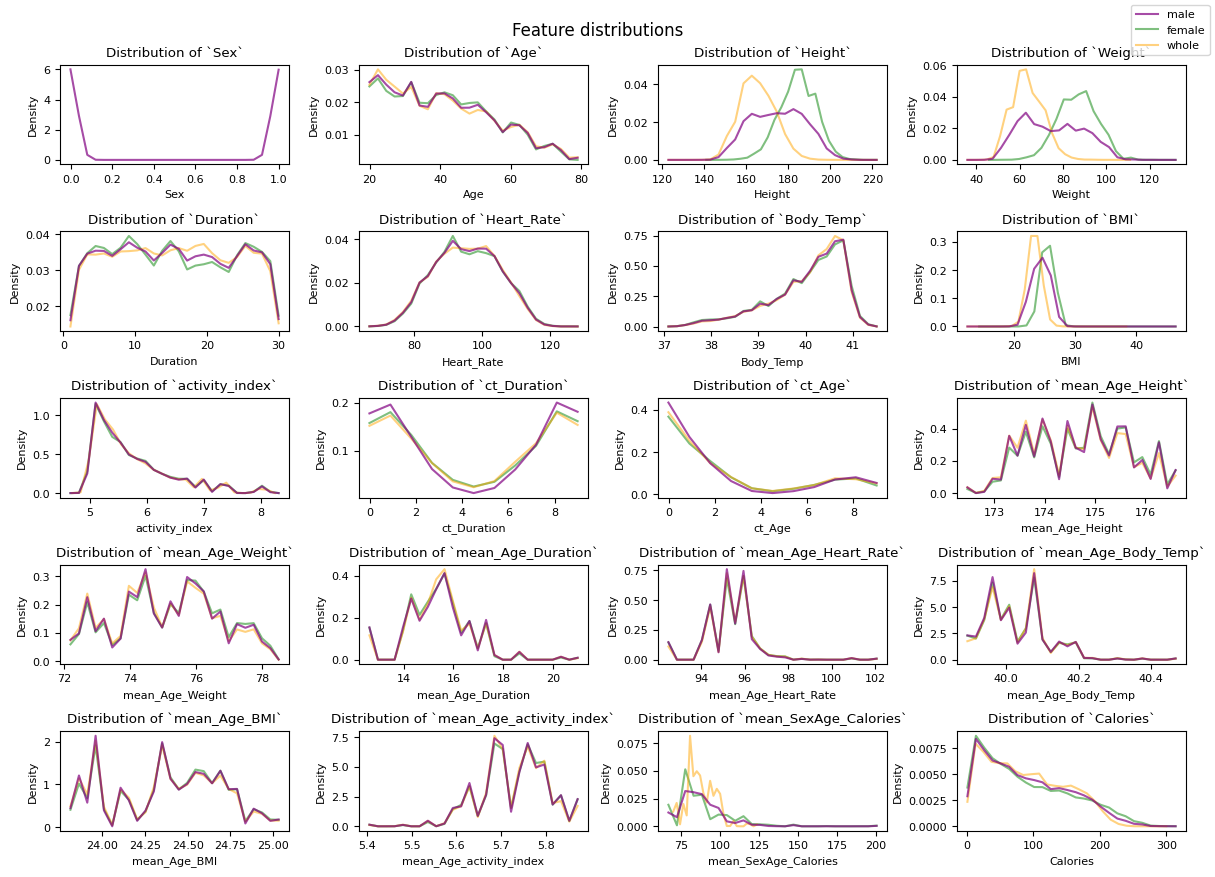

In [128]:
data = X.copy()
data[TARGET] = y

COLUMNS = 4
ROWS = np.ceil(len(data.columns) / COLUMNS).astype(int)
SIZE = (COLUMNS * 3, ROWS * 1.75)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')

MALE = data.Sex == 1
for n, feature in enumerate(data.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if feature == 'Sex':
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=25, color='purple')
    elif feature.startswith('ct_'):
        bins = data[feature].unique().size
        feature_overview(ax[row][col], data.loc[MALE, feature], FigureType.DENSITY, bins=bins, color='green')
        feature_overview(ax[row][col], data.loc[~MALE, feature], FigureType.DENSITY, bins=bins, color='orange')
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=bins, color='purple')
    else:
        feature_overview(ax[row][col], data.loc[MALE, feature], FigureType.DENSITY, bins=25, color='green')
        feature_overview(ax[row][col], data.loc[~MALE, feature], FigureType.DENSITY, bins=25, color='orange')
        feature_overview(ax[row][col], data[feature], FigureType.DENSITY, bins=25, color='purple')

fig.legend(['male', 'female', 'whole'])
plt.show()

__Correlations__

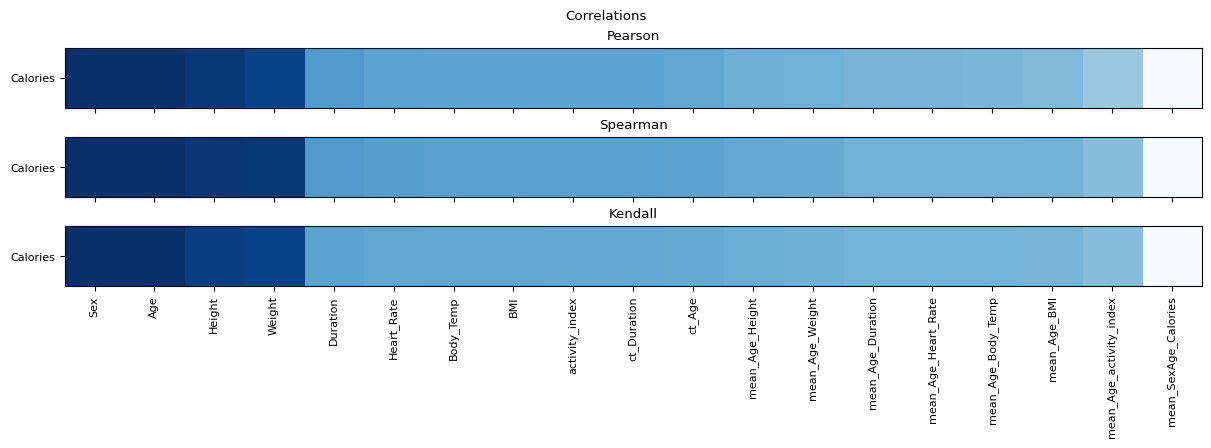

In [129]:
THRESHOLD = 0.0

data = X.copy()
labels = data.columns
data[TARGET] = y

CORRELATIONS = ('pearson', 'spearman', 'kendall')
# CORRELATIONS = ('pearson', )
# drawing
fig, axes = plt.subplots(len(CORRELATIONS), 1, figsize=(12, 4.5), sharex=True)
fig.set_layout_engine('compressed')
fig.suptitle('Correlations')
for n, method in enumerate(CORRELATIONS):
    ax = axes[n] if len(CORRELATIONS) > 1 else axes
    ax.set_title(method.capitalize())
    target_corr = data.corr(method)[[TARGET]].drop(TARGET).sort_values(TARGET, ascending=False)
    values = target_corr.values.squeeze()
    filtered = (abs(values) > THRESHOLD)
    ax.imshow(values[filtered].reshape(1, -1), cmap='Blues')
    ax.set_xticks(range(len(labels[filtered])), labels=labels[filtered], rotation=90)
    ax.set_yticks([0], labels=[TARGET])
plt.show()

__Model Checks__

In [ ]:
E = LGBMRegressor(  # see more https://lightgbm.readthedocs.io/en/latest/Parameters.html
    # objective='gamma',
    # objective='quantile',
    objective='poisson',
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    n_jobs=-1,
    random_state=23,
    verbose=-1,
    # device_type='cuda'
)
_ = checkup(E, X, y, folds=5)
importances = boruta(X, y, deepcopy(E), seed=10, plot=True, alpha=0.95, iterations=10)
lgbm = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05893; | VALID RMSLE=0.06093
Fold: 1; TRAIN RMSLE=0.05875; | VALID RMSLE=0.06135
Fold: 2; TRAIN RMSLE=0.05898; | VALID RMSLE=0.06048
Fold: 3; TRAIN RMSLE=0.05917; | VALID RMSLE=0.05974
Fold: 4; TRAIN RMSLE=0.05887; | VALID RMSLE=0.06051
MEAN: TRAIN RMSLE=0.05894; | VALID RMSLE=0.06060


In [ ]:
# CPU
E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
    objective='Poisson',
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    random_state=23,
    silent=True,
    allow_writing_files=False,
    # task_type='GPU',
)
_ = checkup(E, X, y, folds=5)
importances = boruta(X, y, E.copy(), seed=10, plot=True, alpha=0.95)
catboost = model = E.fit(X, y)

In [ ]:
# # GPU
# E = CatBoostRegressor(  # see more https://catboost.ai/docs/en/concepts/loss-functions-regression
#     objective='Poisson',
#     n_estimators=15000,
#     learning_rate=0.8,
#     max_depth=6,
#     random_state=23,
#     silent=True,
#     allow_writing_files=False,
#     task_type='GPU',
# )
# _ = checkup(E, X, y, folds=5)
# # importances = boruta(X, y, E.copy(), seed=10, plot=True, alpha=0.95)
# catboost = model = E.fit(X, y)

Fold: 0; TRAIN RMSLE=0.05147; | VALID RMSLE=0.06368
Fold: 1; TRAIN RMSLE=0.05118; | VALID RMSLE=0.06492
Fold: 2; TRAIN RMSLE=0.05132; | VALID RMSLE=0.06376
Fold: 3; TRAIN RMSLE=0.05133; | VALID RMSLE=0.06241
Fold: 4; TRAIN RMSLE=0.05136; | VALID RMSLE=0.06426
MEAN: TRAIN RMSLE=0.05133; | VALID RMSLE=0.06381


__Submission__

In [17]:
# LGBM
T = pipe.transform(test.drop(columns=TARGET))
values = lgbm.predict(T)

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

7edb687d6e57408e9c44f72f666b8454


In [44]:
# CatBoost
T = pipe.transform(test.drop(columns=TARGET))
values = catboost.predict(T)

if (test[TARGET] != values).any():
    filecode = uuid.uuid4().hex
    test[TARGET] = values
    test.reset_index()[['id', TARGET]].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

124acf281799470680c6b157b1ec5595


In [ ]:
#